### 비지도학습(센서기반)

In [ ]:
# 온도, 압력, 진동 센서 데이터를 활용한 비지도 학습 기반 이상 탐지 (오토인코더 기반)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # Matplotlib에서 3차원 플롯을 그릴 수 있도록 지원하는 도구

In [ ]:
# 1. 데이터 불러오기
try:
    df_train = pd.read_csv("dataset/train_data.csv")
    df_test = pd.read_csv("dataset/test_data.csv")
except FileNotFoundError:
    print("지정된 경로에 파일이 존재하지 않습니다.")
    exit()

In [ ]:
# 2. 데이터 전처리
# 결측치 확인 및 처리
if df_train.isnull().sum().any() or df_test.isnull().sum().any():  # any() 결측치가 있으면 True, False로 반환
    print("경고: 결측치가 감지되었습니다. 평균값으로 채웁니다.")
    df_train.fillna(df_train.mean(), inplace=True)
    df_test.fillna(df_test.mean(), inplace=True)

# 피처 선택
X_train = df_train[["temperature", "pressure", "vibration"]].values
X_test = df_test[["temperature", "pressure", "vibration"]].values
y_test = df_test["label"].values  # 0 = 정상, 1 = 불량

# 데이터 스케일링 (StandardScaler 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 3. 오토인코더 모델 정의
def build_autoencoder(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        # 인코더
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        # 디코더
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(input_dim, activation=None)
    ])
    return model

# 모델 생성 및 컴파일
autoencoder = build_autoencoder(input_dim=3)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

In [ ]:
# 4. 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# 5. 모델 학습
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.0180 - val_loss: 0.7551
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8212 - val_loss: 0.4234
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4756 - val_loss: 0.2262
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3334 - val_loss: 0.0750
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2283 - val_loss: 0.0413
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2109 - val_loss: 0.0374
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1884 - val_loss: 0.0265
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1612 - val_loss: 0.0225
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1516 - val_loss: 0.0302
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1444 - val_loss: 0.0249
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1623 - val_loss: 0.0251
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

In [ ]:
# 6. 테스트셋에 대한 재구성 오차 계산
X_test_pred = autoencoder.predict(X_test_scaled, verbose=0)
mse = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

In [ ]:
# 7. 임계값 설정 (기존: 95% 백분위)
threshold_percentile = 95   # mse 값 중에서 하위 95% (정상), 상위 5%(불량)
threshold = np.percentile(mse, threshold_percentile)
print(f"Threshold ({threshold_percentile}% percentile): {threshold:.4f}")

Threshold (95% percentile): 6.8052


In [ ]:
# 8. 이상 탐지 결과 (기존 임계값 사용)
y_pred = (mse > threshold).astype(int)


 Classification Report (Threshold based on 95% percentile):
              precision    recall  f1-score   support

      Normal       0.70      1.00      0.83       100
     Anomaly       1.00      0.16      0.28        50

    accuracy                           0.72       150
   macro avg       0.85      0.58      0.55       150
weighted avg       0.80      0.72      0.64       150

 Confusion Matrix (Threshold based on 95% percentile):


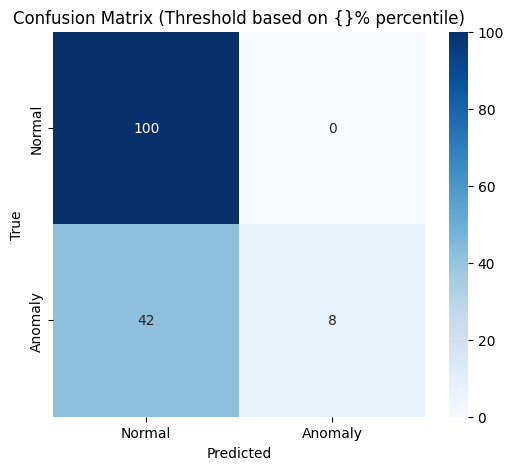

 ROC AUC Score (Threshold based on 95% percentile): 1.0000


In [ ]:
# 9. 평가 (기존 임계값)
print("\n Classification Report (Threshold based on {}% percentile):".format(threshold_percentile))
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))  # Normal(정상), Anomaly(불량)

print(" Confusion Matrix (Threshold based on {}% percentile):".format(threshold_percentile))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Confusion Matrix (Threshold based on {}% percentile)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

roc_auc = roc_auc_score(y_test, mse)
print(f" ROC AUC Score (Threshold based on {threshold_percentile}% percentile): {roc_auc:.4f}")

In [ ]:
# --- 최적 임계값 찾기 (F1 Score 기반) ---
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, mse)  #  이상 탐지 모델의 성능을 다양한 임계값에서 평가하기 위해 사용
f1_scores = 2 * recalls * precisions / (recalls + precisions + 1e-8)  # fl_scores 공식
best_threshold_idx = np.argmax(f1_scores) # f1_scores 배열에서 가장 큰 값의 인덱스(위치)를 찾아냄
best_threshold = thresholds_pr[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\nBest Threshold (based on F1 score): {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")


Best Threshold (based on F1 score): 1.5942
Best F1 Score: 1.0000



 Classification Report (Optimized Threshold based on F1 Score):
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       100
     Anomaly       1.00      0.98      0.99        50

    accuracy                           0.99       150
   macro avg       1.00      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

 Confusion Matrix (Optimized Threshold based on F1 Score):


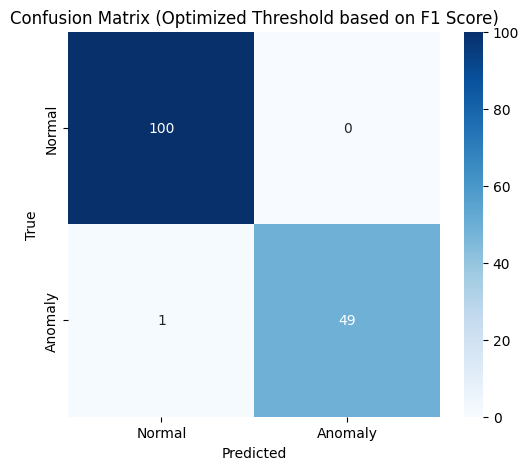

 ROC AUC Score (Optimized Threshold): 1.0000


In [ ]:
# 최적 임계값으로 예측
y_pred_optimized = (mse > best_threshold).astype(int)
print("\n Classification Report (Optimized Threshold based on F1 Score):")
print(classification_report(y_test, y_pred_optimized, target_names=["Normal", "Anomaly"]))

print(" Confusion Matrix (Optimized Threshold based on F1 Score):")
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Confusion Matrix (Optimized Threshold based on F1 Score)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

roc_auc_optimized = roc_auc_score(y_test, mse) # MSE 기반 ROC AUC는 임계값 변경에 영향 없음
print(f" ROC AUC Score (Optimized Threshold): {roc_auc_optimized:.4f}")

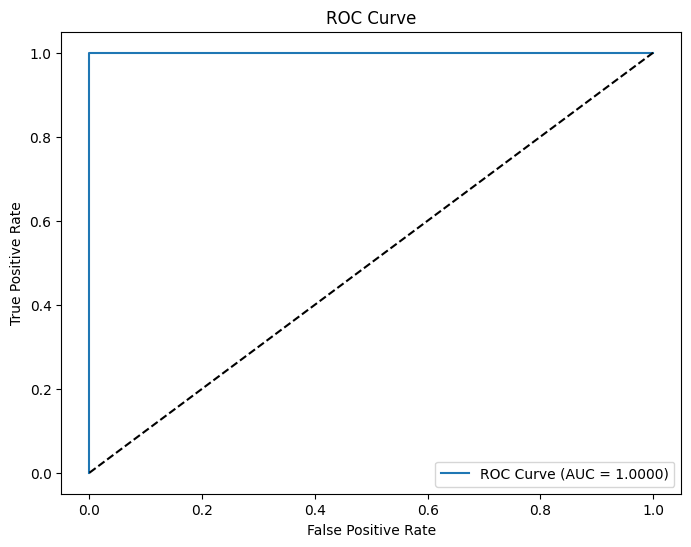

In [ ]:
# 10. ROC 커브 시각화
fpr, tpr, _ = roc_curve(y_test, mse)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

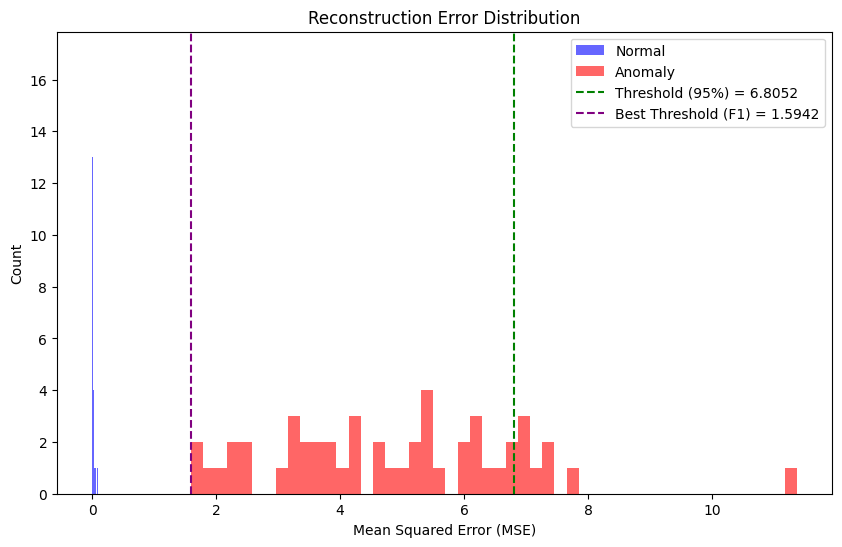

In [ ]:
# 11. 시각화: 재구성 오차 분포
plt.figure(figsize=(10, 6))
plt.hist(mse[y_test == 0], bins=50, alpha=0.6, label="Normal", color='blue')
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, label="Anomaly", color='red')
plt.axvline(threshold, color='green', linestyle='--', label=f'Threshold ({threshold_percentile}%) = {threshold:.4f}')
plt.axvline(best_threshold, color='purple', linestyle='--', label=f'Best Threshold (F1) = {best_threshold:.4f}')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Mean Squared Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.show()

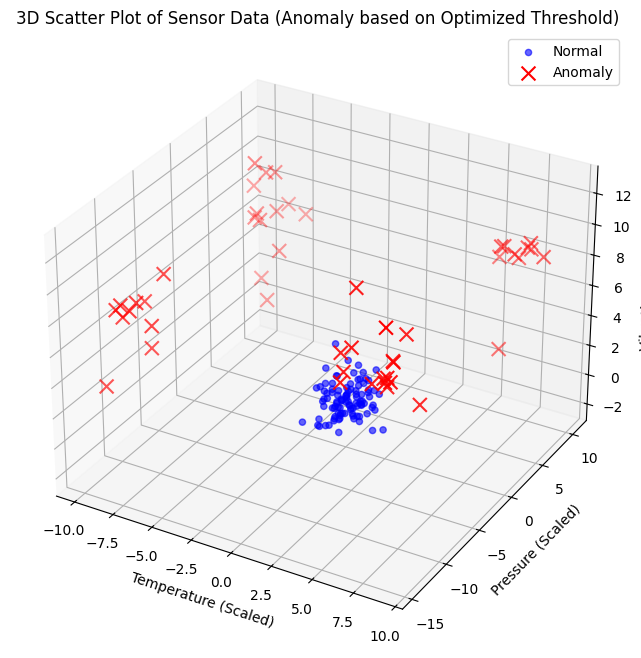

In [ ]:
# 12. 시각화: 3D 산점도
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_scaled[y_test == 0, 0], X_test_scaled[y_test == 0, 1], X_test_scaled[y_test == 0, 2],
           c='blue', label='Normal', alpha=0.6)
ax.scatter(X_test_scaled[y_pred_optimized == 1, 0], X_test_scaled[y_pred_optimized == 1, 1], X_test_scaled[y_pred_optimized == 1, 2],
           c='red', label='Anomaly', marker='x', s=100)
ax.set_xlabel("Temperature (Scaled)")
ax.set_ylabel("Pressure (Scaled)")
ax.set_zlabel("Vibration (Scaled)")
plt.title("3D Scatter Plot of Sensor Data (Anomaly based on Optimized Threshold)")
plt.legend()
plt.show()

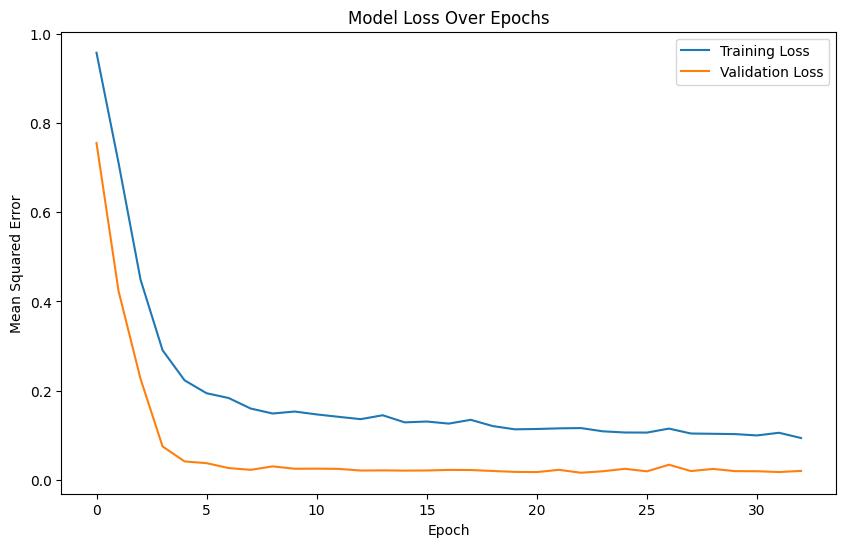

In [ ]:
# 13. 학습 손실 시각화
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [ ]:
# 14. 단일 테스트 데이터 예측
# 예시 데이터: 온도=25.0, 압력=100.0, 진동=0.5
# 필요 시 아래 값을 원하는 데이터로 변경하세요
test_sample = np.array([[25.0, 100.0, 0.5]])
test_sample_scaled = scaler.transform(test_sample)
test_sample_pred = autoencoder.predict(test_sample_scaled, verbose=0)
test_sample_mse = np.mean(np.square(test_sample_scaled - test_sample_pred))
is_anomaly = test_sample_mse > best_threshold # 최적 임계값 사용
print("\n🔍 단일 데이터 예측 결과 (Optimized Threshold):")
print(f"입력 데이터: 온도={test_sample[0, 0]}, 압력={test_sample[0, 1]}, 진동={test_sample[0, 2]}")
print(f"재구성 오차 (MSE): {test_sample_mse:.4f}")
print(f"결과: {'불량 (Anomaly)' if is_anomaly else '정상 (Normal)'}")


🔍 단일 데이터 예측 결과 (Optimized Threshold):
입력 데이터: 온도=25.0, 압력=100.0, 진동=0.5
재구성 오차 (MSE): 0.4986
결과: 정상 (Normal)
